In [66]:
root_backup = "../../../dump"
root = "VA_results"
n = 0
q = 2700
k = 0
m = 1500
window_size = 50
fig_size = (10,8)

In [67]:
grid_styles = [
    {'linestyle': '-', 'linewidth': 0.75, 'alpha': 0.6, 'color': 'gray'},
    {'linestyle': '--', 'linewidth': 1.2, 'alpha': 0.7, 'color': 'tab:red'},
    {'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8, 'color': 'tab:green', 'axis': 'x'},
    {'linestyle': '-.', 'linewidth': 1, 'alpha': 0.6, 'color': 'tab:purple', 'minor': True}
]

3000 3000 3000


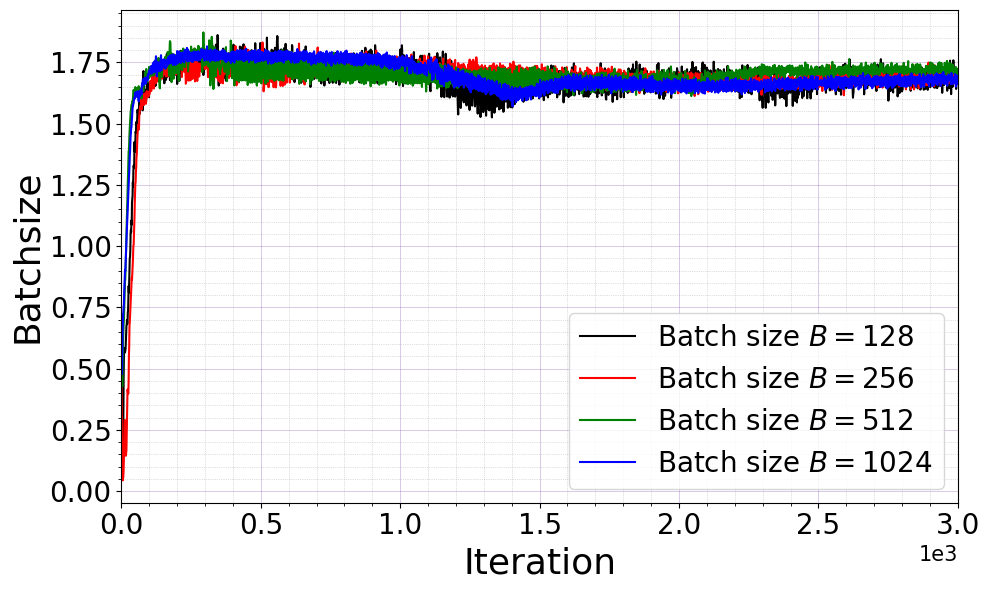

In [71]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import json

# Load the results for each model
def load_results(paths, type="revenue"):
    lenpath = len(paths)
    results = []
    for i in range(lenpath):
        with open(paths[i], "r") as f:
            results.append(json.load(f)[type][n:])
    return results

path_batch_size = [f"../{root_backup}/runs_RegretFormer_batch_size128/setting_default_config_128/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size256/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size512/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size1034/setting_default_config_2_copy_2/seed_1/model_result_3000_5x3_0.001"]
results_VCG = [0.5884, 0.7832, 0.9334]
results_VCG5x3 = [results_VCG[0] for _ in range(3000)]
results_VCG7x3 = [results_VCG[1] for _ in range(3000)]
results_VCG9x3 = [results_VCG[2] for _ in range(3000)]
print(len(results_VCG5x3), len(results_VCG7x3), len(results_VCG9x3))
VCG_auction = [results_VCG5x3, results_VCG7x3, results_VCG9x3]


def plot_columns_from_paths(paths, columns, colors, labels, figsize=(10, 6), pos = "lower right", 
                            type="revenue", xname="Iteration", yname="Batchsize",grid_styles= grid_styles[3], VCG= VCG_auction):

    # Load data from paths
    data = [load_results([path], type=type )[0] for path in paths]
    if VCG is not None and type == "revenue":
        data += VCG

    
    plt.figure(figsize=figsize)

    for dataset, color, dataset_label in zip(data, colors, labels):
        if dataset in VCG:
            plt.plot(range(len(dataset)), dataset, color=color, label =dataset_label, linewidth=2.5)
        else:
            plt.plot(range(len(dataset)), dataset, color=color, label=dataset_label)

        # Configure plot aesthetics
        plt.xlabel(xname, fontsize=26)
        plt.ylabel(yname, fontsize=26)
        # plt.grid(alpha=1, linestyle='-')
        if 'minor' in grid_styles:
            plt.minorticks_on()
            plt.grid(True, which='major', linestyle='-', linewidth=0.5, color='tab:purple', alpha=0.5)
            plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)           

        else:
            plt.grid(**grid_styles)
        plt.legend(fontsize=20, loc=pos)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        plt.xlim(left=0, right=len(dataset))


    # Configure scientific notation on the x-axis
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.xaxis.get_offset_text().set_fontsize(15)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


# Define variables
columns_in_progress = [
    "Batch size $B=128$",
    "Batch size $B=256$",
    "Batch size $B=512$",
    "Batch size $B=1024$",
]
colors = ["black", "red", "green", "blue"]
labels = columns_in_progress

# Call the function with path_batch_size
plot_columns_from_paths(path_batch_size, columns_in_progress, colors, labels, grid_styles=grid_styles[3])

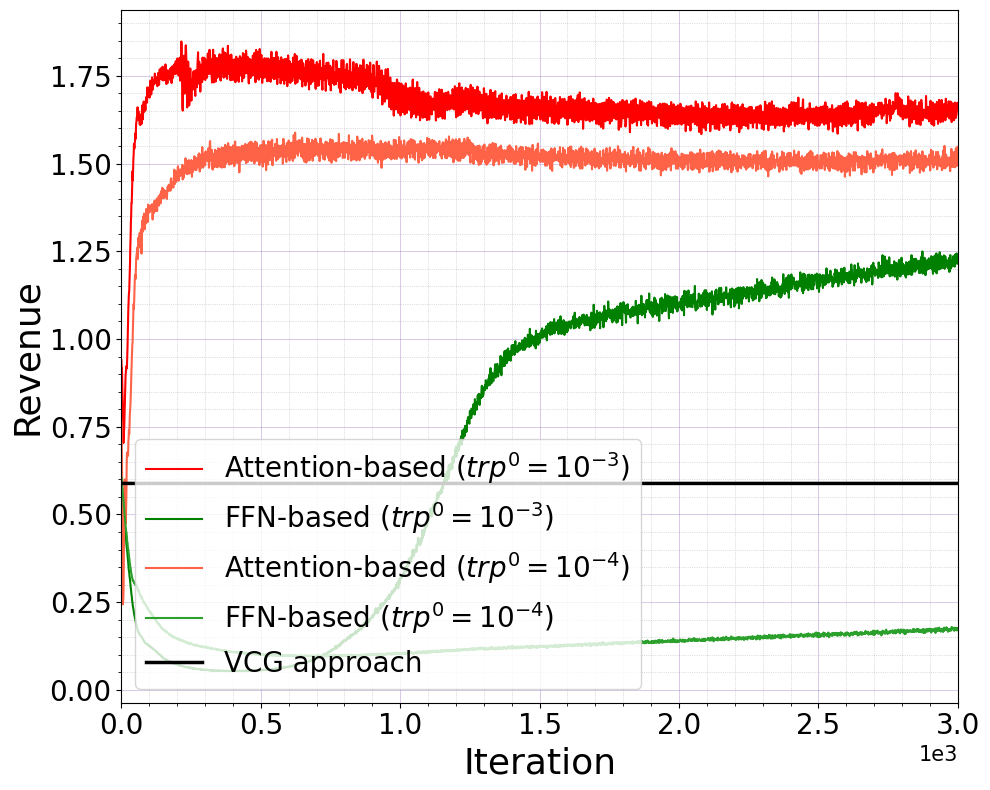

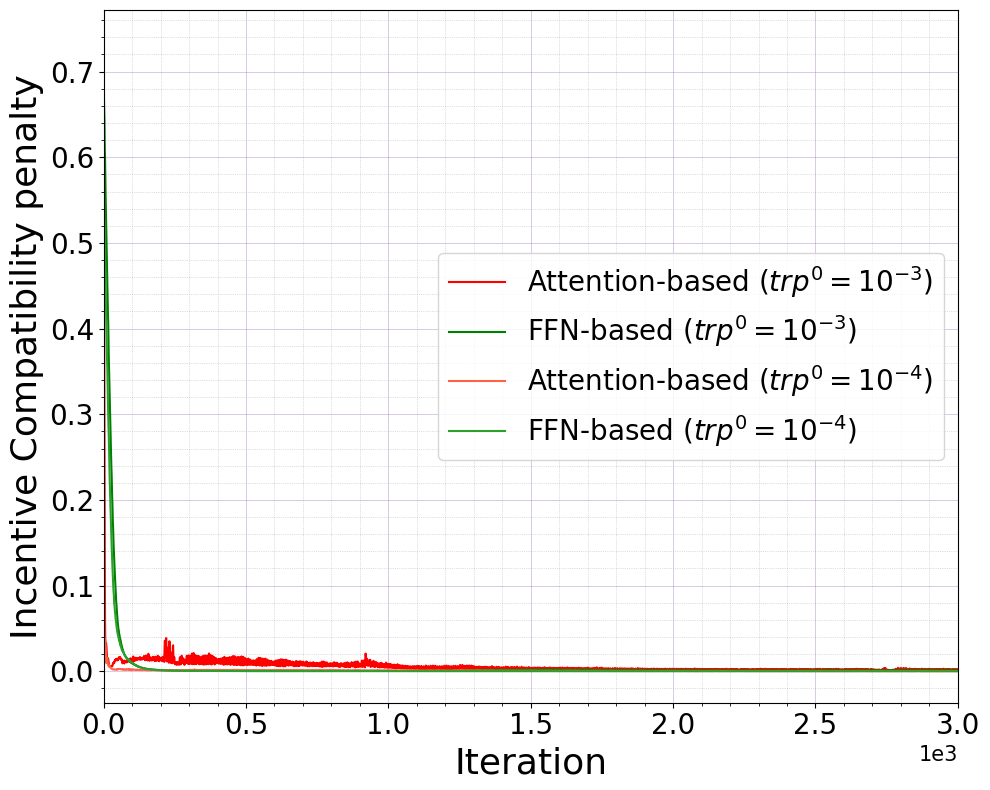

In [72]:
path_trp = ["../runs_RegretFormer/setting_default_config/seed_0/model_result_3000_5x3_0.001",
             "../runs_RegretNet/setting_default_config/seed_0/model_result_3000_5x3_0.001",
             "../runs_RegretFormer/setting_default_config_trp/seed_0/model_result_3000_5x3_0.0001", 
             "../runs_RegretNet/setting_default_config_trp/seed_0/model_result_3000_5x3_0.0001"]



columns_in_progress = [
    "Attention-based ($trp^0= 10^{-3}$)",
    "FFN-based ($trp^0= 10^{-3}$)",
    "Attention-based ($trp^0= 10^{-4}$)",
    "FFN-based ($trp^0= 10^{-4}$)",
    "VCG approach"
]

colors = ["red", "green", "tomato", "tab:green", "black"]
labels = columns_in_progress


plot_columns_from_paths(path_trp, columns_in_progress, colors, labels, figsize=(10,8), type="revenue", xname="Iteration", yname="Revenue", pos="lower left", VCG = [results_VCG5x3])
plot_columns_from_paths(path_trp, columns_in_progress, colors, labels, figsize=(10,8), type="regret", pos="center right", xname="Iteration", yname="Incentive Compatibility penalty")

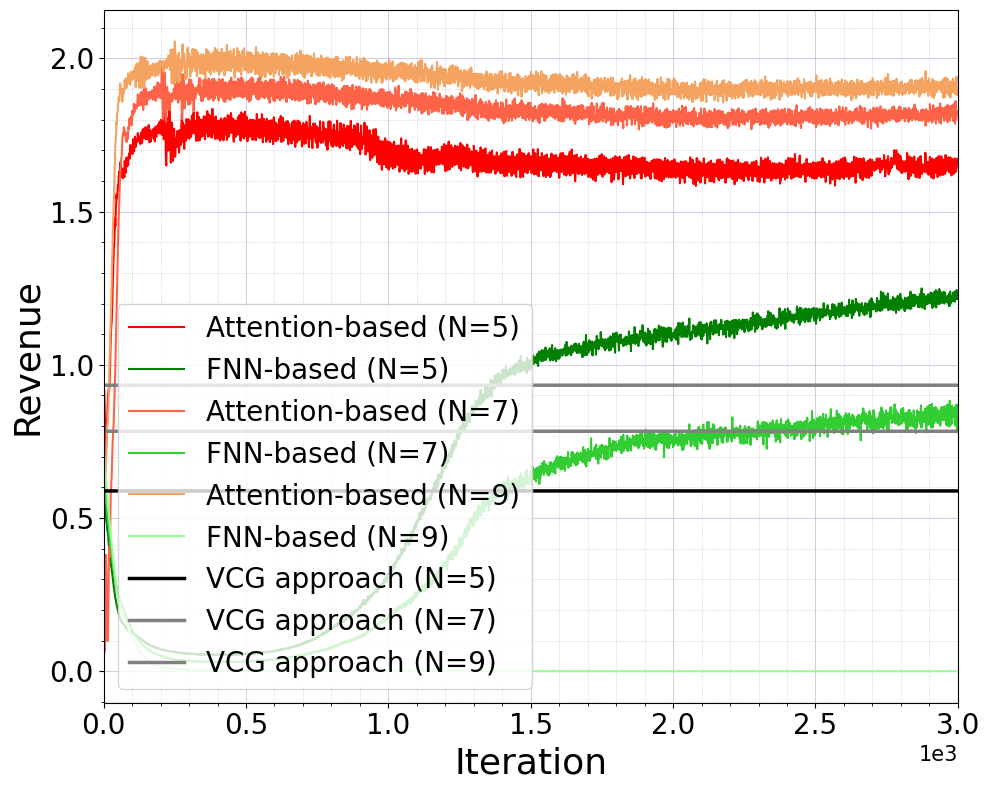

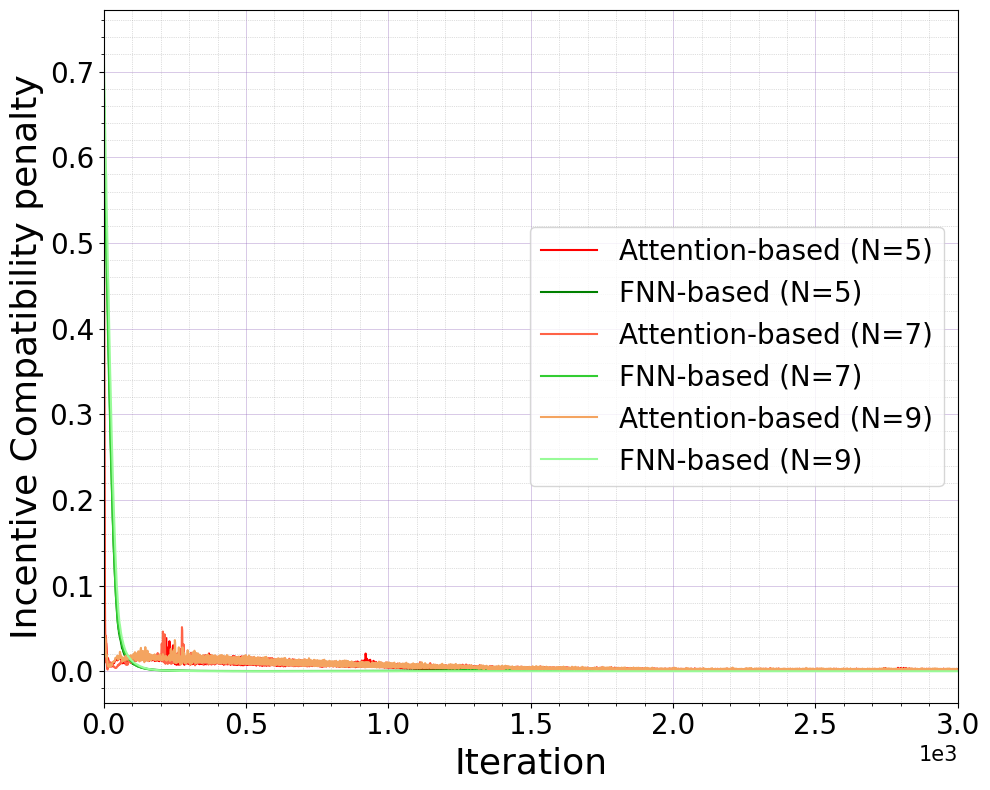

In [73]:
path5x3 = ["../runs_RegretFormer/setting_default_config/seed_0/model_result_3000_5x3_0.001",
           "../runs_RegretNet/setting_default_config/seed_0/model_result_3000_5x3_0.001",
           "../runs_RegretFormer/setting_default_config_2/seed_0/model_result_3000_7x3_0.001",
           "../runs_RegretNet/setting_default_config_2/seed_1/model_result_3000_7x3_0.001",
           "../runs_RegretFormer/setting_default_config_3/seed_1/model_result_3000_9x3_0.001",
           "../runs_RegretNet/setting_default_config_3/seed_1/model_result_3000_9x3_0.001"]

columns_in_progress = [
    "Attention-based (N=5)",
    "FNN-based (N=5)",
    "Attention-based (N=7)",
    "FNN-based (N=7)",
    "Attention-based (N=9)",
    "FNN-based (N=9)",
    "VCG approach (N=5)",
    "VCG approach (N=7)",
    "VCG approach (N=9)"
]

colors = ["red", "green", "tomato", "limegreen", "sandybrown", "palegreen", "black", "gray", "gray"]
labels = columns_in_progress

plot_columns_from_paths(path5x3, columns_in_progress, colors, labels, figsize=(10,8), type="revenue", xname="Iteration", yname="Revenue", pos="lower left", VCG = VCG_auction)
plot_columns_from_paths(path5x3, columns_in_progress, colors, labels, figsize=(10,8), type="regret", pos="center right", xname="Iteration", yname="Incentive Compatibility penalty")